# 🚢 타이타닉 생존자 예측: 탐색적 데이터 분석(EDA) & 머신러닝 파이프라인

이 노트북은 데이터 분석의 전체 사이클을 처음부터 끝까지 실습할 수 있도록 구성되었습니다.

1. **탐색적 데이터 분석 (EDA):** 성별, 객실 등급, 나이, 가족 수가 생존에 미친 영향 시각화
2. **데이터 전처리 & 피처 엔지니어링:** 결측치 대체, 호칭(Title) 추출, 가족 수 파생 변수, 원-핫 인코딩
3. **머신러닝 예측 모델링:** 로지스틱 회귀, 의사결정나무, 랜덤 포레스트 학습 및 비교
4. **모델 평가 및 특성 중요도(Feature Importance):** 어떤 요인이 생존을 결정지었는지 확인
5. **가상 승객 생존 확률 예측 시뮬레이션**

## 0. 라이브러리 준비 및 한글 폰트 설정

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 라이브러리 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


## 1. 데이터 불러오기

In [2]:
df = pd.read_csv("data/Titanic-Dataset.csv")
print(f"데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
df.head()

데이터 크기: 891행 × 12열


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. 탐색적 데이터 분석 (EDA) - 생존율 시각화
승객들의 어떤 특성이 생존율에 큰 영향을 주었는지 차트로 확인합니다.

/var/folders/bf/qpyv75sx5bd3kd5fyh_btfn80000gn/T/ipykernel_36620/2055707550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='pastel')
/var/folders/bf/qpyv75sx5bd3kd5fyh_btfn80000gn/T/ipykernel_36620/2055707550.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Blues_d')
findfont: Failed to find font weight bold, now using 400.


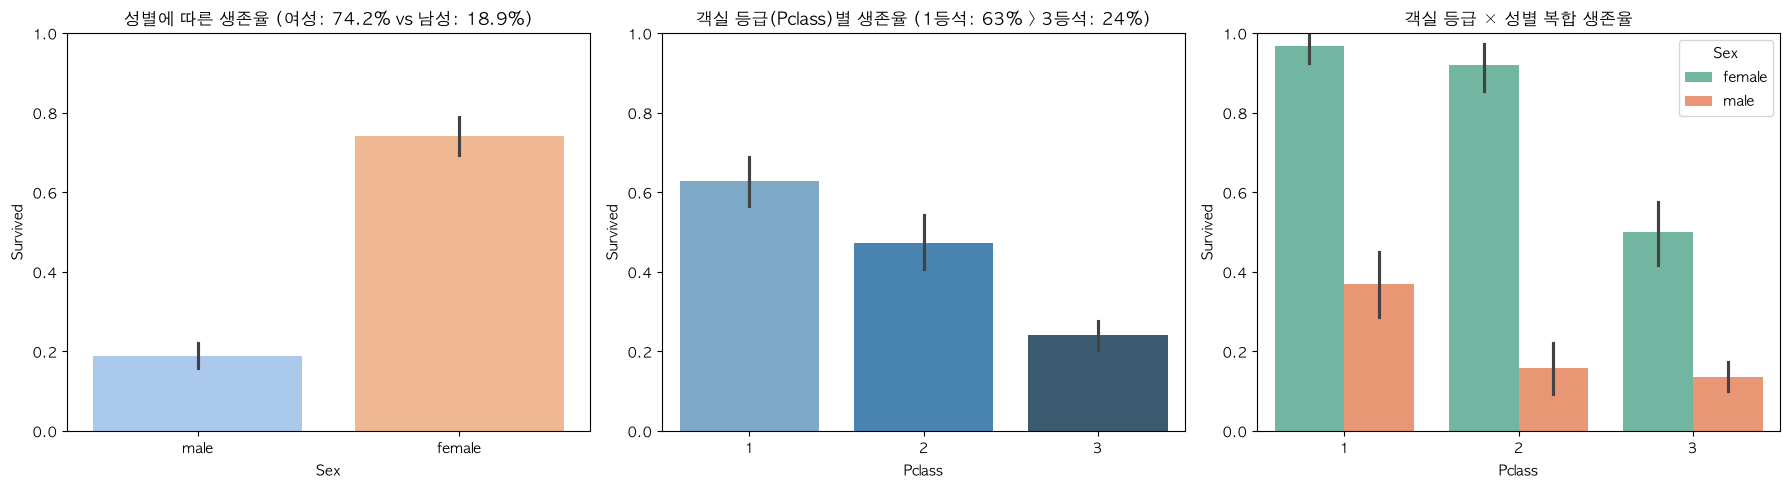

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 성별 생존율
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='pastel')
axes[0].set_title("성별에 따른 생존율 (여성: 74.2% vs 남성: 18.9%)", fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.0)

# 2) 객실 등급(Pclass)별 생존율
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Blues_d')
axes[1].set_title("객실 등급(Pclass)별 생존율 (1등석: 63% > 3등석: 24%)", fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)

# 3) 객실 등급 x 성별 복합 생존율
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[2], palette='Set2')
axes[2].set_title("객실 등급 × 성별 복합 생존율", fontsize=12, fontweight='bold')
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

/var/folders/bf/qpyv75sx5bd3kd5fyh_btfn80000gn/T/ipykernel_36620/2984562554.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df_temp, ax=axes[1], palette='viridis')


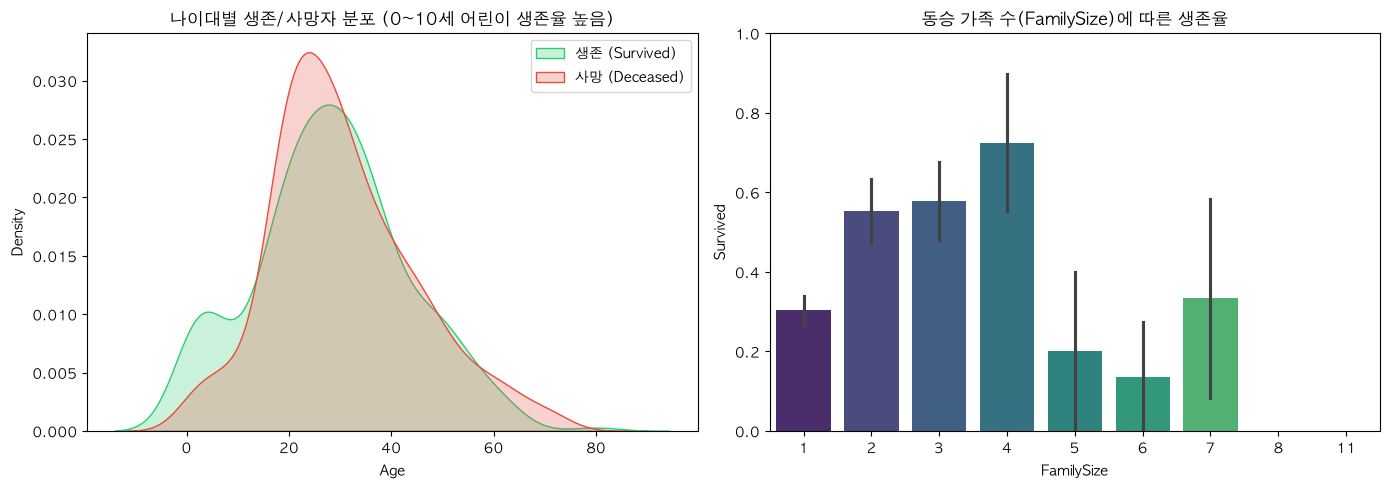

In [4]:
# 나이 및 가족 수에 따른 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 나이별 생존/사망 KDE 곡선
sns.kdeplot(df[df['Survived'] == 1]['Age'].dropna(), ax=axes[0], label='생존 (Survived)', fill=True, color='#2ecc71')
sns.kdeplot(df[df['Survived'] == 0]['Age'].dropna(), ax=axes[0], label='사망 (Deceased)', fill=True, color='#e74c3c')
axes[0].set_title("나이대별 생존/사망자 분포 (0~10세 어린이 생존율 높음)", fontsize=12, fontweight='bold')
axes[0].legend()

# 동승 가족 수
df_temp = df.copy()
df_temp['FamilySize'] = df_temp['SibSp'] + df_temp['Parch'] + 1
sns.barplot(x='FamilySize', y='Survived', data=df_temp, ax=axes[1], palette='viridis')
axes[1].set_title("동승 가족 수(FamilySize)에 따른 생존율", fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 3. 데이터 전처리 & 피처 엔지니어링 (Preprocessing)
머신러닝 알고리즘은 문자열이나 결측치(NaN)를 직접 처리하지 못하므로, 정제 및 숫자 변환 과정을 거칩니다.

In [5]:
data = df.copy()

# 1) 이름(Name)에서 호칭(Title) 추출
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
data['Title'] = data['Title'].apply(lambda x: x if x in common_titles else 'Rare')

# 2) 나이(Age) 결측치: 호칭별 중앙값으로 채우기
for title, med_age in data.groupby('Title')['Age'].median().items():
    data.loc[(data['Age'].isnull()) & (data['Title'] == title), 'Age'] = med_age

# 3) 탑승 항구(Embarked) 결측치: 최빈값 'S'로 채우기
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# 4) 운임 요금(Fare) 로그 변환 (이상치 완화)
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['LogFare'] = np.log1p(data['Fare'])

# 5) 가족 수 및 나홀로 탑승 여부 파생 변수
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# 6) 원-핫 인코딩 (문자열 -> 0, 1 숫자로 변환)
data['Sex_male'] = (data['Sex'] == 'male').astype(int)
data = pd.get_dummies(data, columns=['Embarked', 'Title'], drop_first=True, dtype=int)

# 모델 학습 피처 선택
features = ['Pclass', 'Sex_male', 'Age', 'LogFare', 'FamilySize', 'IsAlone',
            'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

X = data[features]
y = data['Survived']
print("전처리 완료! 피처 목록:", features)
X.head()

전처리 완료! 피처 목록: ['Pclass', 'Sex_male', 'Age', 'LogFare', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


,Pclass,Sex_male,Age,LogFare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,1,22.0,2.110213,2,0,0,1,0,1,0,0
1,1,0,38.0,4.280593,2,0,0,0,0,0,1,0
2,3,0,26.0,2.188856,1,1,0,1,1,0,0,0
3,1,0,35.0,3.990834,2,0,0,1,0,0,1,0
4,3,1,35.0,2.202765,1,1,0,1,0,1,0,0


## 4. 데이터 분할 및 머신러닝 모델 학습
- 데이터를 **학습용(Train, 80%)**과 **테스트용(Test, 20%)**으로 분리합니다.
- 3가지 분류 모델을 동시에 학습시켜 성능을 비교합니다.

In [6]:
# 학습 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3개 모델 정의
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

results = {}
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    trained[name] = model
    print(f"[{name}] 정확도: {acc*100:.2f}%")

[Logistic Regression] 정확도: 82.12%
[Decision Tree] 정확도: 80.45%
[Random Forest] 정확도: 83.24%


## 5. 최적 모델 평가 및 특성 중요도 (Feature Importance)
- **혼동 행렬(Confusion Matrix)**: 모델이 어떤 예측을 맞추고 틀렸는지 정밀 분석
- **특성 중요도**: 모델이 생존을 예측할 때 어떤 변수를 가장 가중치 있게 보았는지 시각화

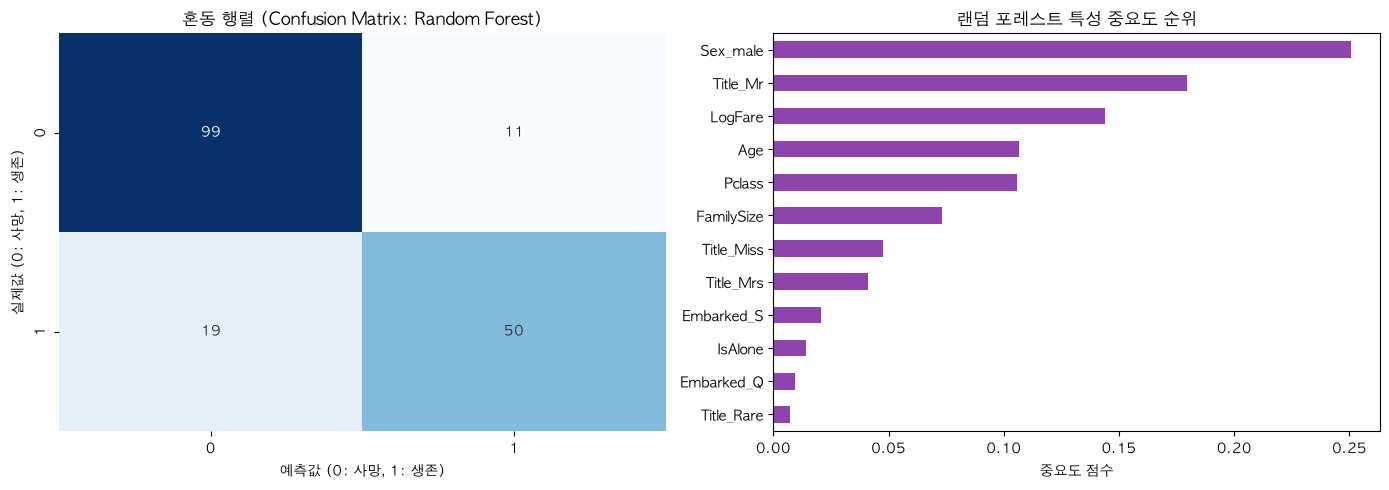

In [7]:
rf_model = trained['Random Forest']
rf_pred = rf_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("혼동 행렬 (Confusion Matrix: Random Forest)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("예측값 (0: 사망, 1: 생존)")
axes[0].set_ylabel("실제값 (0: 사망, 1: 생존)")

# 2) Feature Importance (특성 중요도)
fi = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
fi.plot(kind='barh', ax=axes[1], color='#8e44ad')
axes[1].set_title("랜덤 포레스트 특성 중요도 순위", fontsize=12, fontweight='bold')
axes[1].set_xlabel("중요도 점수")

plt.tight_layout()
plt.show()

## 6. 가상 승객 생존 확률 예측 시뮬레이션
우리가 만든 모델에 가상의 승객 정보를 입력하여 생존 확률을 예측해 봅니다.

In [8]:
# 승객 1: 1등석, 25세 여성 (Miss), 운임 $100
# 승객 2: 3등석, 28세 남성 (Mr), 운임 $8
samples = pd.DataFrame([
    {'Pclass': 1, 'Sex_male': 0, 'Age': 25.0, 'LogFare': np.log1p(100.0), 'FamilySize': 1, 'IsAlone': 1,
     'Embarked_Q': 0, 'Embarked_S': 1, 'Title_Miss': 1, 'Title_Mr': 0, 'Title_Mrs': 0, 'Title_Rare': 0},
    {'Pclass': 3, 'Sex_male': 1, 'Age': 28.0, 'LogFare': np.log1p(8.0), 'FamilySize': 1, 'IsAlone': 1,
     'Embarked_Q': 0, 'Embarked_S': 1, 'Title_Miss': 0, 'Title_Mr': 1, 'Title_Mrs': 0, 'Title_Rare': 0}
])[features]

probs = rf_model.predict_proba(samples)
print("👩 1등석 25세 여성 (Miss) 생존 확률:", f"{probs[0][1]*100:.1f}%")
print("👨 3등석 28세 남성 (Mr) 생존 확률:", f"{probs[1][1]*100:.1f}%")

👩 1등석 25세 여성 (Miss) 생존 확률: 97.7%
👨 3등석 28세 남성 (Mr) 생존 확률: 10.6%
